# Retail Sales Analytics Project

## Data Cleaning, Analysis and Interactive Dashboard

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Plotly
- Streamlit

### Objective
The objective of this project is to clean a raw retail sales dataset, perform exploratory data analysis, calculate business KPIs, identify sales trends, and develop an interactive dashboard for business decision-making.

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Formatting
import matplotlib.ticker as ticker
from matplotlib.patches import Patch, FancyBboxPatch

# Settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")


Retail Sales Analytics Environment Ready


In [32]:
# Load Dataset
df = pd.read_csv("retail_sales.csv")

# Dataset Preview
df.head()

,OrderID,OrderDate,ShipDate,ShipMode,Channel,CustomerID,CustomerName,Email,Phone,Age,Gender,Segment,LoyaltyTier,Region,Country,State,City,PostalCode,Category,SubCategory,ProductID,ProductName,Quantity,UnitPrice,Discount,PromoCode,Sales,Cost,Profit,ProfitMargin,PaymentMethod,SalesRep,Returned
0,ORD-1005371,2021-01-01,2021-01-06,Standard,Phone Order,CUST-104055,Chloe Nguyen,chloe.nguyen5@outlook.com,+1-727-573-1855,51,Male,Corporate,Gold,Asia-Pacific,Singapore,SG,Singapore,01866,Sports & Outdoors,Camping,SPO-CAM-8047,2-Person Tent,8,130.75,0.05,NEWYEAR,993.70,577.76,415.94,41.86,Debit Card,Jessica A.,No
1,ORD-1005791,2021-01-01,2021-01-07,Standard,Online,CUST-101234,Richard Gonzalez,richard.gonzalez57@hotmail.com,+1-647-352-2293,40,Other,Consumer,Gold,Asia-Pacific,Singapore,SG,Singapore,01840,Technology,Printers,TEC-PRI-7017,InkTank 3000,1,185.55,0.15,NEWYEAR,157.72,130.39,27.33,17.33,Apple Pay,Ananya D.,No
2,ORD-1008078,2021-01-01,2021-01-07,Standard,Phone Order,CUST-105358,Barbara Smith,barbara.smith1996@proton.me,+1-500-343-1036,56,Male,Home Office,Silver,North America - Central,USA,TX,Houston,77056,Sports & Outdoors,Cycling,SPO-CYC-8606,Helmet,1,40.12,0.00,NaN,40.12,19.63,20.49,51.07,Debit Card,Liam C.,No
3,ORD-1009062,2021-01-01,2021-01-08,Standard,Phone Order,CUST-103845,Sarah Sharma,sarahsharma1975@company.com,+1-471-298-3265,34,Female,Corporate,Gold,Asia-Pacific,Singapore,SG,Singapore,01866,Office Supplies,Pens,OFF-PEN-2077,Gel Pen 12pk,4,4.82,0.00,NaN,19.28,7.24,12.04,62.45,Debit Card,Diego S.,No
4,ORD-1009733,2021-01-01,2021-01-06,Standard,Mobile App,CUST-102577,Karen Miller,karen.miller24@hotmail.com,+1-308-547-5047,55,Male,Corporate,Silver,North America - Central,USA,TX,Houston,77083,Technology,Accessories,TEC-ACC-1667,USB-C Hub,1,39.79,0.00,NaN,39.79,22.91,16.88,42.42,Credit Card,Priya C.,No


In [33]:
print("Dataset Information")
print("-" * 50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        80000 non-null  object 
 1   OrderDate      80000 non-null  object 
 2   ShipDate       80000 non-null  object 
 3   ShipMode       80000 non-null  object 
 4   Channel        80000 non-null  object 
 5   CustomerID     80000 non-null  object 
 6   CustomerName   80000 non-null  object 
 7   Email          80000 non-null  object 
 8   Phone          80000 non-null  object 
 9   Age            80000 non-null  int64  
 10  Gender         80000 non-null  object 
 11  Segment        80000 non-null  object 
 12  LoyaltyTier    80000 non-null  object 
 13  Region         80000 non-null  object 
 14  Country        80000 non-null  object 
 15  State          80000 non-null  object 
 16  City           80000 no

### Observation

- Dataset contains 80,000 records and 33 columns.
- Most columns have complete data.
- PromoCode column has some missing values.
- OrderDate and ShipDate need datetime conversion.

In [ ]:
# Descriptive Statistics
df.describe()

,Age,Quantity,UnitPrice,Discount,Sales,Cost,Profit,ProfitMargin
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,46.416288,3.068888,138.988253,0.059041,401.075780,283.361530,117.714250,37.431444
std,16.763616,2.817111,206.726931,0.096494,898.771145,683.937175,254.173333,13.805342
min,18.000000,1.000000,4.250000,0.000000,2.990000,1.800000,-2351.490000,-36.470000
25%,32.000000,1.000000,37.190000,0.000000,54.477500,32.010000,19.380000,29.560000
50%,46.000000,2.000000,61.400000,0.000000,136.490000,83.960000,47.280000,39.040000
75%,61.000000,4.000000,146.800000,0.100000,360.485000,236.600000,116.100000,47.090000
max,75.000000,15.000000,1139.960000,0.300000,17092.200000,11862.300000,6829.350000,69.900000


### Observation

- Average sales per order is $401.
- Average profit per order is $118.
- Customers purchase around 3 products per order.
- Highest sale recorded was $17,092.
- A few orders generated losses.

In [36]:
# Handling Missing Values
df['PromoCode'] = df['PromoCode'].fillna('No Promo')
# Check for any remaining null values
print("Null Values in Each Column")
print("-" * 50)
df.isnull().sum()

Null Values in Each Column
--------------------------------------------------


OrderID          0
OrderDate        0
ShipDate         0
ShipMode         0
Channel          0
CustomerID       0
CustomerName     0
Email            0
Phone            0
Age              0
Gender           0
Segment          0
LoyaltyTier      0
Region           0
Country          0
State            0
City             0
PostalCode       0
Category         0
SubCategory      0
ProductID        0
ProductName      0
Quantity         0
UnitPrice        0
Discount         0
PromoCode        0
Sales            0
Cost             0
Profit           0
ProfitMargin     0
PaymentMethod    0
SalesRep         0
Returned         0
dtype: int64

In [38]:
# Duplicate Records
print("Duplicate Records")
print("-" * 50)
df[df.duplicated()]

Duplicate Records
--------------------------------------------------


,OrderID,OrderDate,ShipDate,ShipMode,Channel,CustomerID,CustomerName,Email,Phone,Age,Gender,Segment,LoyaltyTier,Region,Country,State,City,PostalCode,Category,SubCategory,ProductID,ProductName,Quantity,UnitPrice,Discount,PromoCode,Sales,Cost,Profit,ProfitMargin,PaymentMethod,SalesRep,Returned


In [43]:
# Change the data type of 'ShipDate' and 'OrderDate' columns to datetime YYYY-MM-DD format
df['ShipDate'] = pd.to_datetime(df['ShipDate'], format='%Y-%m-%d')
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='%Y-%m-%d')
# Check the data types of the columns after conversion
print("Data Types After Conversion")
print("-" * 50)
df.info()
# Dataset Preview
print("Dataset Preview")
print("-" * 50)
df.head()

Data Types After Conversion
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        80000 non-null  object        
 1   OrderDate      80000 non-null  datetime64[ns]
 2   ShipDate       80000 non-null  datetime64[ns]
 3   ShipMode       80000 non-null  object        
 4   Channel        80000 non-null  object        
 5   CustomerID     80000 non-null  object        
 6   CustomerName   80000 non-null  object        
 7   Email          80000 non-null  object        
 8   Phone          80000 non-null  object        
 9   Age            80000 non-null  int64         
 10  Gender         80000 non-null  object        
 11  Segment        80000 non-null  object        
 12  LoyaltyTier    80000 non-null  object        
 13  Region         80000 non-null  object     

,OrderID,OrderDate,ShipDate,ShipMode,Channel,CustomerID,CustomerName,Email,Phone,Age,Gender,Segment,LoyaltyTier,Region,Country,State,City,PostalCode,Category,SubCategory,ProductID,ProductName,Quantity,UnitPrice,Discount,PromoCode,Sales,Cost,Profit,ProfitMargin,PaymentMethod,SalesRep,Returned
0,ORD-1005371,2021-01-01,2021-01-06,Standard,Phone Order,CUST-104055,Chloe Nguyen,chloe.nguyen5@outlook.com,+1-727-573-1855,51,Male,Corporate,Gold,Asia-Pacific,Singapore,SG,Singapore,01866,Sports & Outdoors,Camping,SPO-CAM-8047,2-Person Tent,8,130.75,0.05,NEWYEAR,993.70,577.76,415.94,41.86,Debit Card,Jessica A.,No
1,ORD-1005791,2021-01-01,2021-01-07,Standard,Online,CUST-101234,Richard Gonzalez,richard.gonzalez57@hotmail.com,+1-647-352-2293,40,Other,Consumer,Gold,Asia-Pacific,Singapore,SG,Singapore,01840,Technology,Printers,TEC-PRI-7017,InkTank 3000,1,185.55,0.15,NEWYEAR,157.72,130.39,27.33,17.33,Apple Pay,Ananya D.,No
2,ORD-1008078,2021-01-01,2021-01-07,Standard,Phone Order,CUST-105358,Barbara Smith,barbara.smith1996@proton.me,+1-500-343-1036,56,Male,Home Office,Silver,North America - Central,USA,TX,Houston,77056,Sports & Outdoors,Cycling,SPO-CYC-8606,Helmet,1,40.12,0.00,No Promo,40.12,19.63,20.49,51.07,Debit Card,Liam C.,No
3,ORD-1009062,2021-01-01,2021-01-08,Standard,Phone Order,CUST-103845,Sarah Sharma,sarahsharma1975@company.com,+1-471-298-3265,34,Female,Corporate,Gold,Asia-Pacific,Singapore,SG,Singapore,01866,Office Supplies,Pens,OFF-PEN-2077,Gel Pen 12pk,4,4.82,0.00,No Promo,19.28,7.24,12.04,62.45,Debit Card,Diego S.,No
4,ORD-1009733,2021-01-01,2021-01-06,Standard,Mobile App,CUST-102577,Karen Miller,karen.miller24@hotmail.com,+1-308-547-5047,55,Male,Corporate,Silver,North America - Central,USA,TX,Houston,77083,Technology,Accessories,TEC-ACC-1667,USB-C Hub,1,39.79,0.00,No Promo,39.79,22.91,16.88,42.42,Credit Card,Priya C.,No


In [44]:
# Convert Money Columns to Numeric and Remove Dollar Signs and Commas
money_cols = ['Sales', 'Profit', 'Cost','ProfitMargin','UnitPrice']

for col in money_cols:
    df[col] = df[col].replace(r'[$,]', '', regex=True).astype(float)

In [45]:
# Fix Object Columns: typos, extra spaces, and inconsistent capitalization
obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.title()
    )

In [46]:
# Standardize the 'Returned' column to have consistent values
df['Returned'] = (
    df['Returned']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'y': 'Yes',
        'yes': 'Yes',
        'true': 'Yes',
        '1': 'Yes',
        'n': 'No',
        'no': 'No',
        'false': 'No',
        '0': 'No'
    })
)

# Verify the result
print(df['Returned'].unique())

['No' 'Yes']


In [48]:
# Identify and Handle Negative or Zero Quantities

print("Negative or Zero Quantities")
print("-" * 50)
df[df['Quantity'] <= 0]

Negative or Zero Quantities
--------------------------------------------------


,OrderID,OrderDate,ShipDate,ShipMode,Channel,CustomerID,CustomerName,Email,Phone,Age,Gender,Segment,LoyaltyTier,Region,Country,State,City,PostalCode,Category,SubCategory,ProductID,ProductName,Quantity,UnitPrice,Discount,PromoCode,Sales,Cost,Profit,ProfitMargin,PaymentMethod,SalesRep,Returned


In [49]:
# Save the cleaned dataset to a new CSV file
df.to_csv('retail_sales_cleaned.csv', index=False)

# Exploratory Data Analysis(EDA)

In [50]:
# Create a copy of the cleaned DataFrame for further analysis
df_copy = df.copy()

### Monthly Sales Trend with Seasonal Peaks

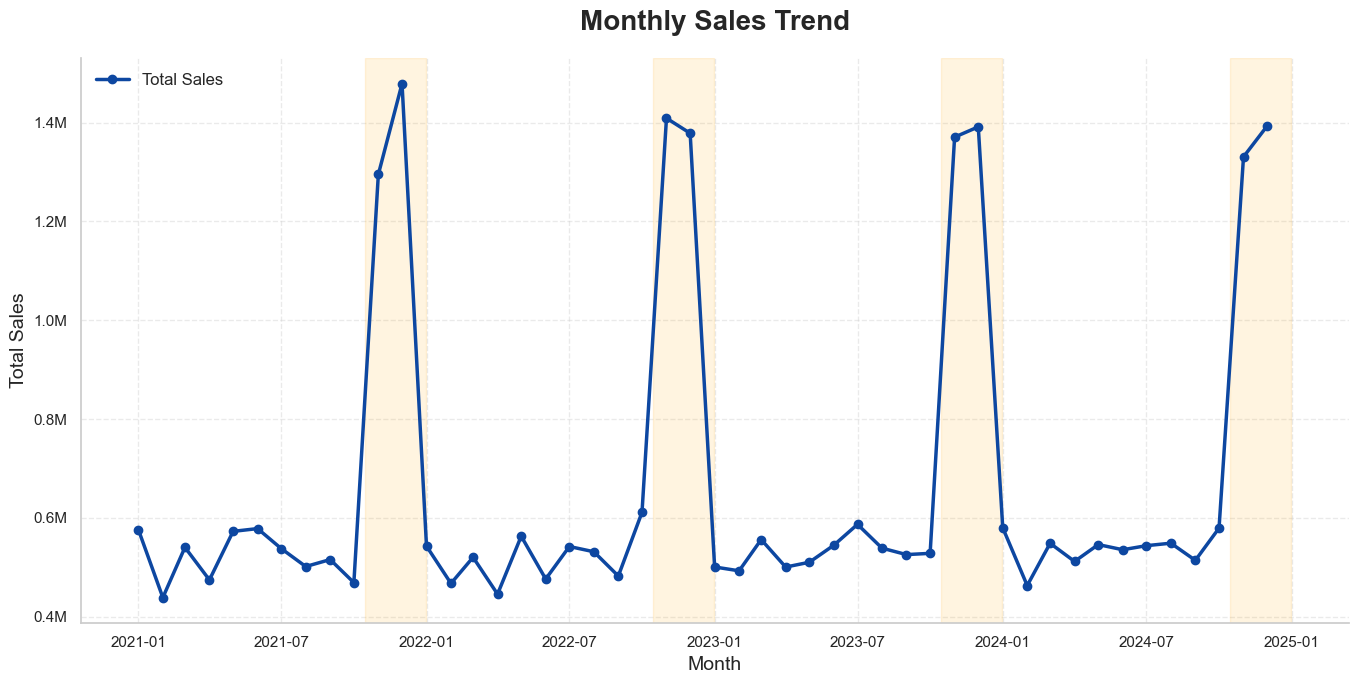

In [20]:
# Create Year-Month column
df_copy['YearMonth'] = df_copy['OrderDate'].dt.to_period('M')

# Monthly Sales
monthly_sales = df_copy.groupby('YearMonth')['Sales'].sum()

# Convert PeriodIndex to Timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Create Figure
plt.figure(figsize=(14,7), facecolor='white')

# Main Line
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2.5,
    markersize=6,
    color='#0D47A1',
    label='Total Sales'
)

# Highlight Nov-Dec each year
for year in [2021, 2022, 2023, 2024]:
    plt.axvspan(
        pd.Timestamp(f'{year}-10-15'),
        pd.Timestamp(f'{year}-12-31'),
        alpha=0.12,
        color='orange'
    )

# Titles
plt.title(
    'Monthly Sales Trend',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Legend
plt.legend(fontsize=12)

# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Format Y-axis with commas
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
plt.show()

#### Observation

- Sales are mostly between $0.45M and $0.60M in normal months.
- Sales increase a lot during the end of every year.
- Highest sales are seen in November and December.
- The same pattern is repeated every year.
- This shows that year-end season is very important for the business.

###	Regional Sales and Profit Comparison

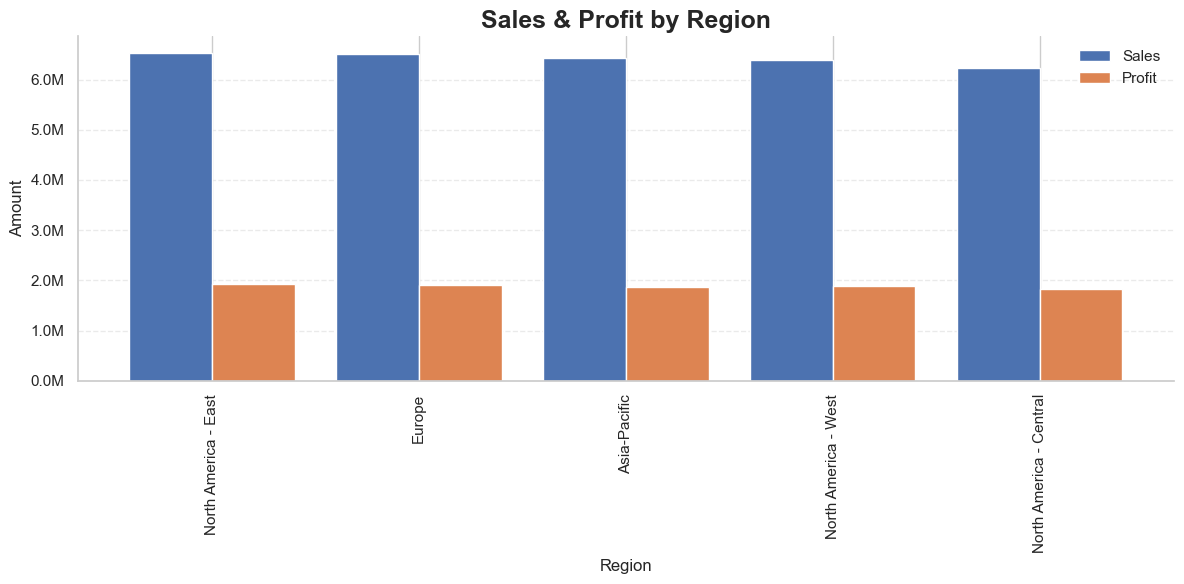

In [51]:
# Group data by Region
region_summary = (
    df_copy.groupby('Region')[['Sales', 'Profit']]
    .sum()
    .sort_values('Sales', ascending=False)
)

# Create chart
ax = region_summary.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8
)

# Title and labels
plt.title(
    'Sales & Profit by Region',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Region', fontsize=12)
plt.ylabel('Amount', fontsize=12)

# Format Y-axis in Millions
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
plt.legend(['Sales', 'Profit'])

plt.tight_layout()
plt.show()

#### Observation

- Sales are almost equal in all regions.
- North America - East has the highest sales.
- North America - Central has the lowest sales.
- Profit is also similar across regions.
- Every region generated profit.

#### 	Category and Sub-Category Sales Analysis

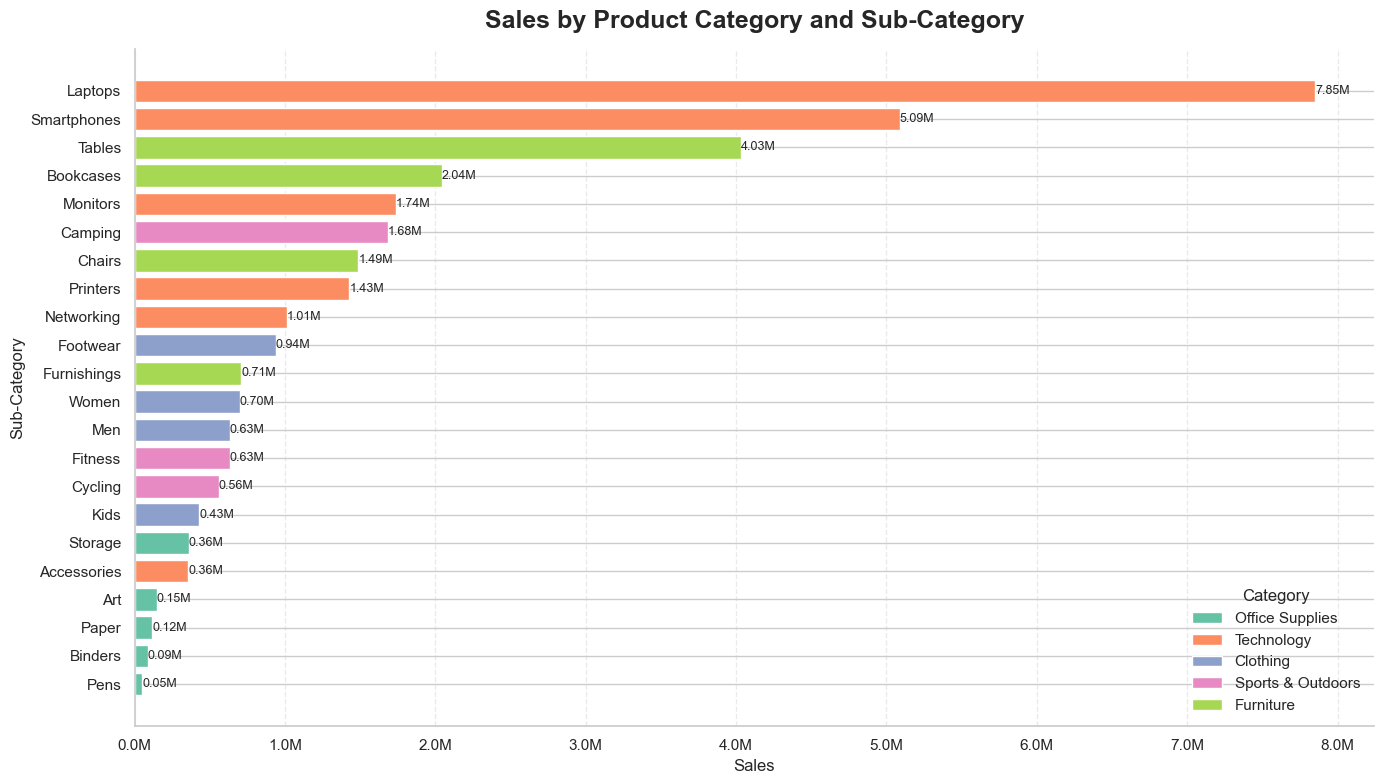

In [52]:


# Group sales by Category and SubCategory
sales_data = (
    df_copy.groupby(['Category', 'SubCategory'])['Sales']
    .sum()
    .reset_index()
    .sort_values('Sales', ascending=True)
)

# Get unique categories
categories = sales_data['Category'].unique()

# Generate colors automatically
palette = sns.color_palette("Set2", len(categories))
category_colors = dict(zip(categories, palette))

# Map colors to each subcategory
colors = sales_data['Category'].map(category_colors)

# Create figure
plt.figure(figsize=(14, 8), facecolor='white')

# Horizontal bars
bars = plt.barh(
    sales_data['SubCategory'],
    sales_data['Sales'],
    color=colors
)

# Title
plt.title(
    'Sales by Product Category and Sub-Category',
    fontsize=18,
    fontweight='bold',
    pad=15
)

# Labels
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)

# Format X-axis in Millions
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width()/1e6:.2f}M',
        va='center',
        fontsize=9
    )

# Create legend
legend_handles = [
    Patch(
        facecolor=category_colors[cat],
        label=cat
    )
    for cat in categories
]

plt.legend(
    handles=legend_handles,
    title='Category',
    loc='lower right'
)

# Grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Layout
plt.tight_layout()

# Show plot
plt.show()

####  Observation

- Technology is the top-selling category.
- Laptops have the highest sales.
- Smartphones and Tablets also performed well.
- Office Supplies have lower sales compared to other categories.
- A few products contribute most of the revenue.

### Year-over-Year Sales Performance

In [53]:
# Extract Year
df_copy['Year'] = df_copy['OrderDate'].dt.year

# Yearly Sales
yearly_sales = (
    df_copy.groupby('Year')['Sales']
    .sum()
    .reset_index()
)

# YoY Growth %
yearly_sales['YoY Growth %'] = (
    yearly_sales['Sales'].pct_change() * 100
)

print(yearly_sales)

   Year       Sales  YoY Growth %
0  2021  7977893.29           NaN
1  2022  7968706.58     -0.115152
2  2023  8045618.77      0.965178
3  2024  8093843.75      0.599394


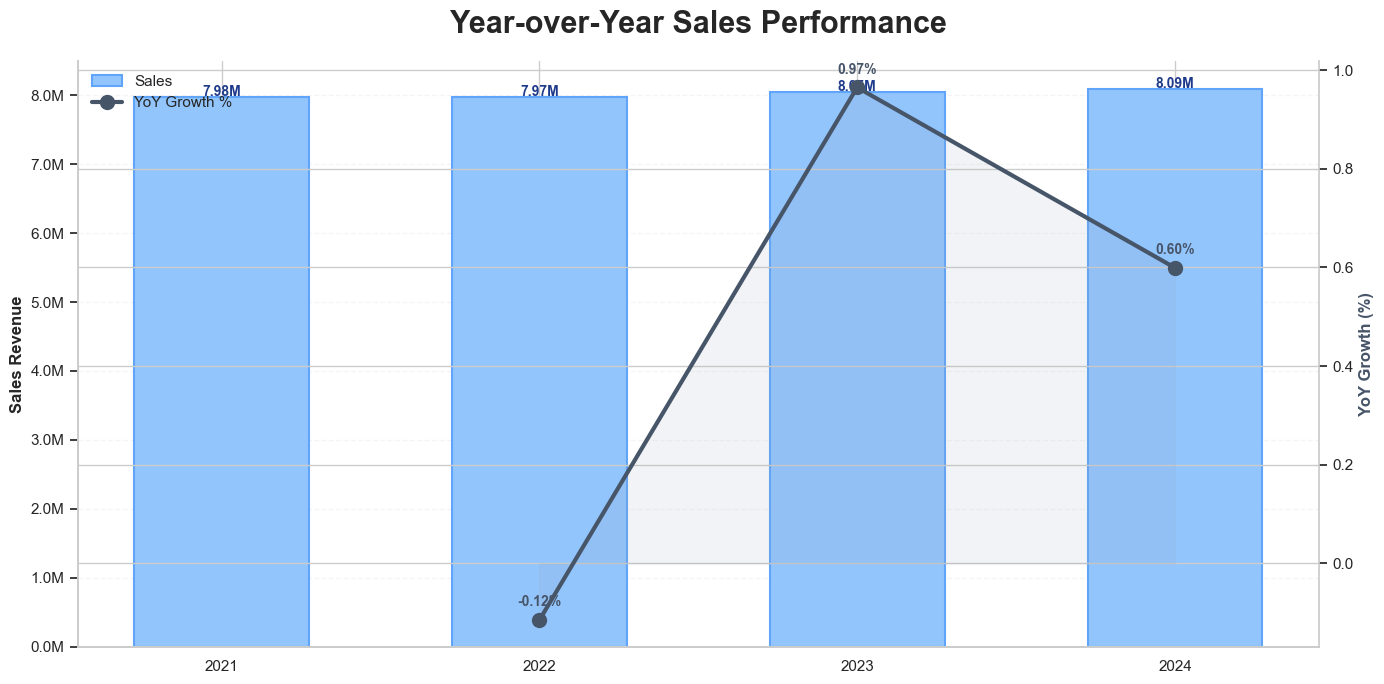

In [ ]:
# Extract Year
df_copy['Year'] = df_copy['OrderDate'].dt.year

# Yearly Sales
yearly_sales = (
    df_copy.groupby('Year')['Sales']
    .sum()
    .reset_index()
)

# YoY Growth %
yearly_sales['YoY Growth %'] = (
    yearly_sales['Sales'].pct_change() * 100
)

# Figure
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')

# Sales Bars (Light Blue)
bars = ax1.bar(
    yearly_sales['Year'].astype(str),
    yearly_sales['Sales'],
    color='#93C5FD',
    edgecolor='#60A5FA',
    linewidth=1.5,
    width=0.55,
    label='Sales'
)

# Sales Labels
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15000,
        f'{bar.get_height()/1e6:.2f}M',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#1E3A8A'
    )

# Left Axis
ax1.set_ylabel(
    'Sales Revenue',
    fontsize=12,
    fontweight='bold'
)

ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'{x/1e6:.1f}M'
    )
)

# Right Axis
ax2 = ax1.twinx()

# Slate Gray Growth Line
ax2.plot(
    yearly_sales['Year'].astype(str),
    yearly_sales['YoY Growth %'],
    color='#475569',
    marker='o',
    markersize=10,
    linewidth=3,
    label='YoY Growth %'
)

# Light Fill
ax2.fill_between(
    yearly_sales['Year'].astype(str),
    yearly_sales['YoY Growth %'],
    alpha=0.12,
    color='#94A3B8'
)

# Growth Labels
for x, y in zip(
    yearly_sales['Year'].astype(str),
    yearly_sales['YoY Growth %']
):
    if pd.notna(y):
        ax2.annotate(
            f'{y:.2f}%',
            (x, y),
            textcoords='offset points',
            xytext=(0, 10),
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='#475569'
        )

# Right Axis Label
ax2.set_ylabel(
    'YoY Growth (%)',
    fontsize=12,
    fontweight='bold',
    color='#475569'
)

# Title
plt.title(
    'Year-over-Year Sales Performance',
    fontsize=22,
    fontweight='bold',
    pad=20
)

# Grid
ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.2
)

# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    frameon=False,
    loc='upper left'
)

# Clean Look
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

- Sales remained almost stable from 2021 to 2024.
- A small decline was seen in 2022.
- Sales increased again in 2023 and reached the highest value.
- 2024 continued the positive growth trend.
- Overall business performance remained consistent over the four years.

### Business Performance Overview

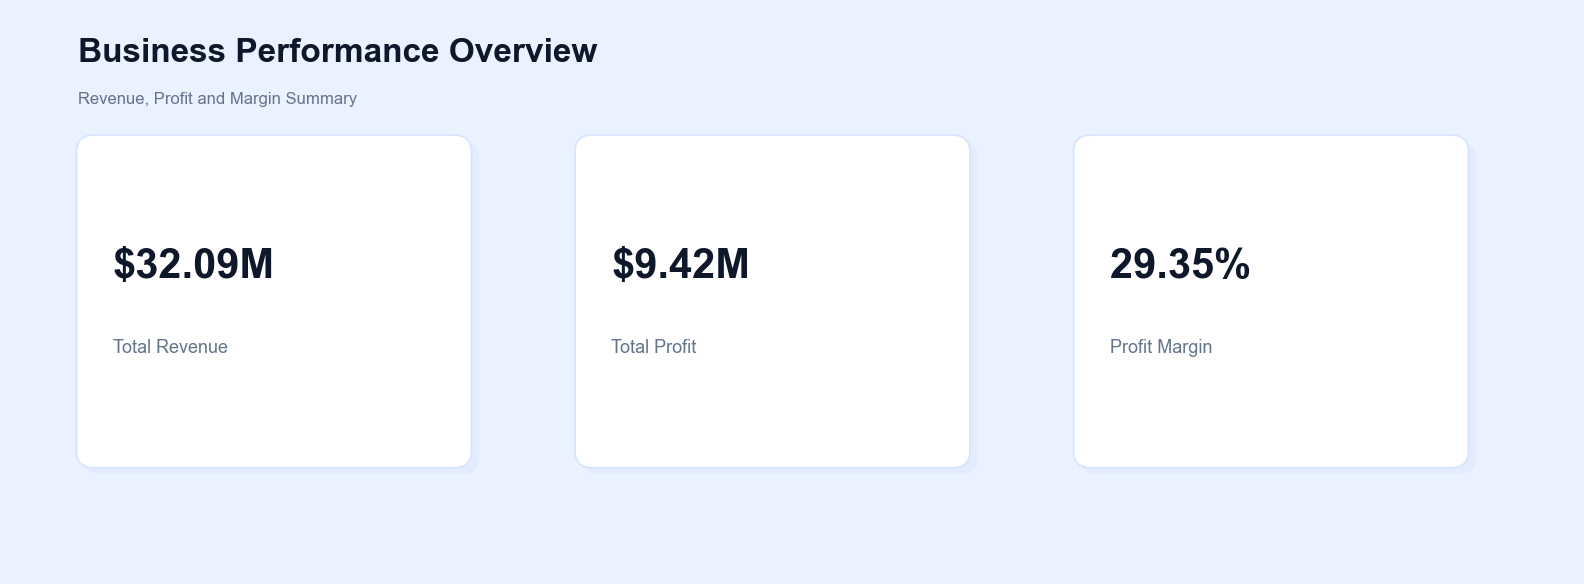

In [55]:

# KPIs
total_revenue = df_copy['Sales'].sum()
total_profit = df_copy['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100

# Figure
fig, ax = plt.subplots(figsize=(16, 6))

# Premium Dashboard Background
fig.patch.set_facecolor('#EAF2FF')

ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis('off')

# Card Function
def create_card(x, value, label):

    # Soft Shadow
    shadow = FancyBboxPatch(
        (x + 0.08, 1.08),
        4,
        3.5,
        boxstyle="round,pad=0.02,rounding_size=0.18",
        linewidth=0,
        facecolor='#BFCFEF',
        alpha=0.15
    )
    ax.add_patch(shadow)

    # Main Card
    card = FancyBboxPatch(
        (x, 1.15),
        4,
        3.5,
        boxstyle="round,pad=0.02,rounding_size=0.18",
        linewidth=1.2,
        edgecolor='#D6E4FF',
        facecolor='#FFFFFF'
    )

    ax.add_patch(card)

    # Value
    ax.text(
        x + 0.35,
        3.15,
        value,
        fontsize=30,
        fontweight='bold',
        color='#0F172A'
    )

    # Label
    ax.text(
        x + 0.35,
        2.35,
        label,
        fontsize=13,
        color='#64748B'
    )

# KPI Cards
create_card(
    0.7,
    f"${total_revenue/1e6:.2f}M",
    "Total Revenue"
)

create_card(
    5.8,
    f"${total_profit/1e6:.2f}M",
    "Total Profit"
)

create_card(
    10.9,
    f"{profit_margin:.2f}%",
    "Profit Margin"
)

# Main Title
ax.text(
    0.7,
    5.45,
    "Business Performance Overview",
    fontsize=24,
    fontweight='bold',
    color='#0F172A'
)

# Subtitle
ax.text(
    0.7,
    5.0,
    "Revenue, Profit and Margin Summary",
    fontsize=12,
    color='#64748B'
)

plt.tight_layout()
plt.show()

### Average Order Value (AOV)

In [56]:

# Calculate AOV
aov = (
    df_copy['Sales'].sum() /
    df_copy['OrderID'].nunique()
)

# Optional Target
target_aov = 250

fig = go.Figure(go.Indicator(
    mode="gauge+number+delta",

    value=aov,

    number={
        'prefix': '$',
        'font': {'size': 40}
    },

    delta={
        'reference': target_aov,
        'relative': True,
        'valueformat': '.1%'
    },

    title={
        'text': "<b>Average Order Value (AOV)</b>"
    },

    gauge={
        'axis': {'range': [0, max(aov*1.3, target_aov*1.3)]},

        'bar': {
            'color': '#2563EB',
            'thickness': 0.35
        },

        'bgcolor': 'white',

        'steps': [
            {'range': [0, target_aov*0.7], 'color': '#FEE2E2'},
            {'range': [target_aov*0.7, target_aov], 'color': '#FEF3C7'},
            {'range': [target_aov, max(aov*1.3, target_aov*1.3)], 'color': '#DCFCE7'}
        ],

        'threshold': {
            'line': {
                'color': '#0F172A',
                'width': 4
            },
            'value': target_aov
        }
    }
))

fig.update_layout(
    height=500,
    width=850,
    paper_bgcolor='#EEF4FF',
    font=dict(
        family='Arial',
        size=16
    )
)

fig.show()

### Observation

- Average Order Value is $401.
- Customers spend around $401 per order.

### Top 10 Customers

In [59]:
top_10_customers = (
    df.groupby("CustomerName")["Sales"]
      .sum()
      .nlargest(10)
      .reset_index()
)

top_10_customers

,CustomerName,Sales
0,Linda Hernandez,65371.28
1,James Wilson,64102.85
2,Noah Brown,62408.51
3,Linda Martinez,61525.28
4,Thomas Tanaka,60230.78
5,William Costa,59843.27
6,Ananya Jones,59686.53
7,Lucas Chen,58255.38
8,Jennifer Cohen,57517.97
9,Sofia Reyes,57374.76


### Return Rate And Repeat Customer Rate

In [58]:
# Return Rate
return_rate = (
    (df_copy['Returned'] == 'Yes').sum()
    / len(df_copy)
) * 100

# Repeat Customer Rate
customer_orders = df_copy.groupby('CustomerID')['OrderID'].nunique()

repeat_customers = (customer_orders > 1).sum()

repeat_customer_rate = (
    repeat_customers /
    customer_orders.count()
) * 100

print(f"Return Rate: {return_rate:.1f}%")
print(f"Repeat Customer Rate: {repeat_customer_rate:.1f}%")

Return Rate: 4.1%
Repeat Customer Rate: 100.0%


#### Observation

- Return rate is 4.1%.
- Only a small percentage of orders were returned.
- Most transactions were completed successfully.

# Key Business Insights

1. Technology category generated the highest sales revenue.

2. Laptop products contributed the most revenue among all sub-categories.

3. Sales increased significantly during the year-end season every year.

4. Revenue and profit were distributed evenly across regions.

5. Return rate remained low at 4.1%, indicating good product performance.

# Recommendations

1. Focus more marketing efforts on high-performing technology products.

2. Increase inventory before the year-end sales season to meet higher demand.

3. Strengthen customer retention programs for top customers.

4. Monitor low-performing product categories and improve promotional strategies.

5. Continue maintaining a low return rate through quality control and customer support.

# Conclusion

The retail sales dataset was analyzed to understand business performance, customer behavior, product trends, and regional sales patterns. The analysis showed strong performance in the technology category, consistent year-end sales growth, balanced regional contribution, and a low return rate. The interactive dashboard provides real-time insights that can support business decision-making and future sales strategies.